![CCAI 9012 course banner](../../../docs/figs/brand_identity/banner.png)

# From a Trained Model to an Interactive Predictor

Imagine that another team has already trained a house-price model. Your job is to turn it into a small, understandable tool that lets a user change inputs, request a prediction, and inspect what the model does.

By the end of this notebook, you should be able to:

- explain how an ML model becomes part of an interactive system;
- trace the path from **inputs → model → output**;
- use a prediction-versus-ground-truth plot as a first model check;
- experiment with a fixed trained model without changing its weights.


## Recap: three phases of the model workflow

The earlier MLP notebook focused on the first two phases: **training** and **validation**. It learned candidate weights from labelled examples, then compared candidates to choose a fixed configuration.

This notebook begins after those model-development decisions have been made. It uses the checked model in the third phase: first **testing**, then **inference** for a new input.


## From model development to model use

The first two phases develop the model; the third phase checks and applies it. The distinction matters because each phase has a different data contract and a different question.

- **Training:** Can the model learn a useful mapping from labelled examples?
- **Validation:** Which candidate configuration should we keep?
- **Testing and inference:** Does the selected model generalise to held-out labelled data, and what does it predict for a new unlabelled case?

| Phase | Data used | Main job | What changes? |
|---|---|---|---|
| 1. Training | Training dataset: features + labels | Learn candidate weights. | The weights update. |
| 2. Validation | Validation dataset: features + labels | Compare candidates and choose a configuration. | The model choice may change. |
| 3. Testing and inference | Test dataset: features + labels; then new inputs: features only | Check the selected model once, then apply it to a new case. | The weights stay fixed. |


> **Key idea:** testing checks a selected model against known labels. Inference applies that same fixed model to a case where the label is not yet available.
> The interface does not retrain or improve the model. It makes the final inference step **usable and inspectable**.


## Workflow: testing and inference

<img src="ml_lifecycle_overview.svg" alt="Overview of training, validation, testing, and inference; the final inference path is highlighted as this notebook's focus" width="100%">

*Figure 1. Training, validation, and testing/inference use different datasets and serve different purposes.*

The earlier notebook covered the training and validation paths on the left. Here we focus on the highlighted third phase. A **test dataset** still has labels, so it can provide one final error check. A **new inference input** has the same eight features but no label; we standardise it in the same way and pass it through the fixed model.

The model expects a precise **input contract**: the same eight features, in the same order and units, with the same preprocessing used during training. If that contract changes, the prediction is no longer trustworthy.

## Step 1 — Load the data and the trained model

Run the next cell. It loads:

- the California housing data;
- a two-layer neural network with eight inputs;
- the saved weights in `mlp_california.pth`;
- a local map image used later by the interface.

You do not need to understand every helper function yet. First, look for the final confirmation message.


In [1]:
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import HTML, display
from matplotlib.ticker import FuncFormatter

plt.rcParams['figure.dpi'] = 110

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'housing_price_california.csv').exists():
    # This fallback supports running the notebook from the repository root.
    NOTEBOOK_DIR = Path.cwd() / 'weekly_scripts' / 'wip' / 'california_housing_model_ui'

DATA_PATH = NOTEBOOK_DIR / 'housing_price_california.csv'
WEIGHTS_PATH = NOTEBOOK_DIR / 'mlp_california.pth'
BASEMAP_PATH = NOTEBOOK_DIR / 'california_osm_z6.png'
FEATURES = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
            'Population', 'AveOccup', 'Latitude', 'Longitude']
FEATURE_LABELS = {
    'MedInc': 'Median income ($10,000)',
    'HouseAge': 'House age (years)',
    'AveRooms': 'Average rooms per household',
    'AveBedrms': 'Average bedrooms per household',
    'Population': 'Population',
    'AveOccup': 'Average occupants per household',
    'Latitude': 'Latitude (degrees)',
    'Longitude': 'Longitude (degrees)',
}
# Cached OpenStreetMap tiles: zoom 6, x=9..11, y=23..26.
WEB_MERCATOR_RADIUS = 6_378_137.0
OSM_TILE_ZOOM = 6
OSM_TILE_RANGE = (9, 12, 23, 27)  # west x, east x, north y, south y (east/south exclusive)
OSM_BASEMAP = plt.imread(BASEMAP_PATH)

def tile_x_to_longitude(tile_x, zoom):
    return tile_x / (2 ** zoom) * 360.0 - 180.0

def tile_y_to_latitude(tile_y, zoom):
    mercator_n = np.pi * (1.0 - 2.0 * tile_y / (2 ** zoom))
    return np.degrees(np.arctan(np.sinh(mercator_n)))

def lonlat_to_web_mercator(longitude, latitude):
    longitude = np.asarray(longitude, dtype=float)
    latitude = np.clip(np.asarray(latitude, dtype=float), -85.0511, 85.0511)
    x = WEB_MERCATOR_RADIUS * np.radians(longitude)
    y = WEB_MERCATOR_RADIUS * np.log(np.tan(np.pi / 4.0 + np.radians(latitude) / 2.0))
    return x, y

def web_mercator_to_longitude(x):
    return np.degrees(x / WEB_MERCATOR_RADIUS)

def web_mercator_to_latitude(y):
    return np.degrees(2.0 * np.arctan(np.exp(y / WEB_MERCATOR_RADIUS)) - np.pi / 2.0)

tile_west, tile_east = [tile_x_to_longitude(x, OSM_TILE_ZOOM) for x in OSM_TILE_RANGE[:2]]
tile_north, tile_south = [tile_y_to_latitude(y, OSM_TILE_ZOOM) for y in OSM_TILE_RANGE[2:]]
osm_x_min, osm_y_min = lonlat_to_web_mercator(tile_west, tile_south)
osm_x_max, osm_y_max = lonlat_to_web_mercator(tile_east, tile_north)

housing = pd.read_csv(DATA_PATH).drop(columns='Unnamed: 0', errors='ignore')
X = housing[FEATURES].astype(np.float32)
y = housing['Target'].astype(float)
feature_mean = X.mean().to_numpy(dtype=np.float32)
feature_std = X.std(ddof=0).to_numpy(dtype=np.float32)

class CaliforniaHousingMLP(torch.nn.Module):
    """The fixed architecture used by the packaged checkpoint."""

    def __init__(self):
        super().__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Linear(8, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 1),
        )

    def forward(self, inputs):
        return self.model(inputs)

model = CaliforniaHousingMLP()
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location='cpu', weights_only=True))
model.eval()
print(f'Loaded fixed inference model and {len(housing):,} dataset rows.')

Loaded fixed inference model and 20,640 dataset rows.


### What are the model inputs and output?

Each row represents a California census block group rather than one individual house.

| Input feature | Plain-language meaning |
|---|---|
| `MedInc` | Median household income, in units of $10,000 |
| `HouseAge` | Median house age, in years |
| `AveRooms` | Average rooms per household |
| `AveBedrms` | Average bedrooms per household |
| `Population` | Block-group population |
| `AveOccup` | Average occupants per household |
| `Latitude`, `Longitude` | Geographic coordinates |

The output is the block group's median house value in units of **$100,000**. For example, an output of `2.50` means approximately `$250,000`.


## Step 2 — Check predictions against ground truth

Before predicting with new input, ask a basic question: **do predictions broadly agree with observed target values?**

The next cell draws a prediction-versus-ground-truth scatter plot. A perfect model would place every point on the diagonal dashed line.

This checkpoint stores weights but not the original train/test row indices. We therefore use a fixed 20% **classroom evaluation sample** to practise reading the plot. It is a diagnostic, not a new claim about unseen-data performance.

Before running the cell, make a prediction:

- Will errors look equally large for low- and high-value block groups?
- Where might the points spread furthest from the diagonal?


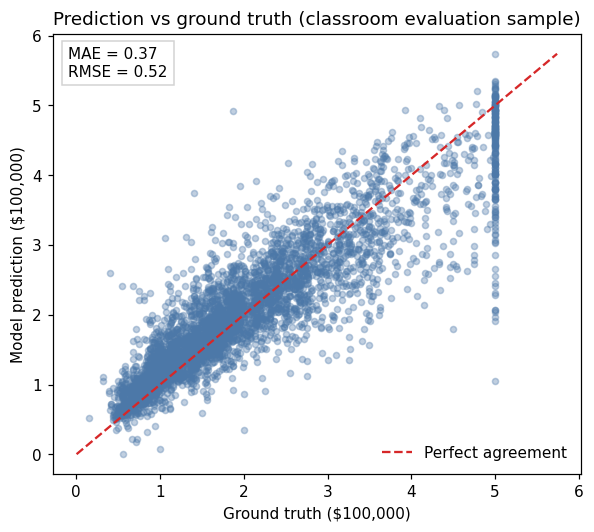

In [2]:
# Create a reproducible sample for a classroom model check.
rng = np.random.default_rng(42)
evaluation_idx = rng.choice(len(X), size=int(0.20 * len(X)), replace=False)
X_evaluation = X.iloc[evaluation_idx].to_numpy(dtype=np.float32)
y_evaluation = y.iloc[evaluation_idx].to_numpy(dtype=float)

X_evaluation_scaled = (X_evaluation - feature_mean) / feature_std
with torch.no_grad():
    evaluation_predictions = (
        model(torch.tensor(X_evaluation_scaled, dtype=torch.float32))
        .squeeze(1)
        .numpy()
    )

mae = np.mean(np.abs(evaluation_predictions - y_evaluation))
rmse = np.sqrt(np.mean((evaluation_predictions - y_evaluation) ** 2))

fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.scatter(y_evaluation, evaluation_predictions, s=16, alpha=0.35, color="#4C78A8")
plot_min = min(y_evaluation.min(), evaluation_predictions.min())
plot_max = max(y_evaluation.max(), evaluation_predictions.max())
ax.plot([plot_min, plot_max], [plot_min, plot_max], "--", color="#D62728", label="Perfect agreement")
ax.set(
    title="Prediction vs ground truth (classroom evaluation sample)",
    xlabel="Ground truth ($100,000)",
    ylabel="Model prediction ($100,000)",
)
ax.legend(frameon=False)
ax.text(
    0.03, 0.97, f"MAE = {mae:.2f}\nRMSE = {rmse:.2f}",
    transform=ax.transAxes, va="top",
    bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "#cccccc"},
)
plt.show()


### Pause and read the plot

- Points close to the dashed diagonal have similar predicted and observed values.
- A point above the line is an **overprediction**; a point below it is an **underprediction**.
- `MAE` summarizes the average absolute error. `RMSE` gives extra weight to larger errors.

Discuss with a partner: would a good average score guarantee that every individual prediction is trustworthy? Why not?


## Step 3 — Trace one input through the model

Inference begins with one row of eight numbers. The model cannot read labels such as “coastal neighbourhood”; it only receives the ordered numeric vector.

Run the cell and compare the displayed feature values with the prediction. Notice the three operations: **select → standardize → predict**.


In [3]:
# Select one example row and turn its eight features into a model input.
reference_features = X.iloc[0]
reference_vector = reference_features.to_numpy(dtype=np.float32)
reference_scaled = (reference_vector - feature_mean) / feature_std

with torch.no_grad():
    reference_prediction = model(torch.tensor(reference_scaled[None, :])).item()

display(reference_features.to_frame(name="Input value"))
print(f"Model prediction: {reference_prediction:.3f} × $100,000")
print(f"Displayed estimate: ${reference_prediction * 100_000:,.0f}")


,Input value
MedInc,8.325200
HouseAge,41.000000
AveRooms,6.984127
AveBedrms,1.023810
Population,322.000000
AveOccup,2.555556
Latitude,37.880001
Longitude,-122.230003


Model prediction: 4.259 × $100,000
Displayed estimate: $425,862


## Step 4 — Try it out with different inputs！

The sliders below build the same kind of eight-number vector. Changing a slider only edits the proposed input. Clicking **Run prediction** sends that vector through preprocessing and the fixed model, then refreshes the visual feedback.

Try this sequence:

1. Start with **Dataset median** and run a prediction.
2. Switch to **Coastal example** and run again. What changes?
3. Change only one feature and rerun. This is a controlled one-feature experiment.
4. Choose the same feature under **Sensitivity feature** and compare your result with the green response curve.


In [4]:
quantiles = X.quantile([0.01, 0.99])
profiles = {
    'Dataset median': X.median(),
    'Coastal example': X.iloc[(housing['Longitude'] < -121).to_numpy().nonzero()[0][0]],
    'Inland example': X.iloc[(housing['Longitude'] > -120).to_numpy().nonzero()[0][0]],
}

def slider_spec(feature):
    low, high = float(quantiles.loc[0.01, feature]), float(quantiles.loc[0.99, feature])
    if feature in {'HouseAge', 'Population'}:
        low, high = int(np.floor(low)), int(np.ceil(high))
        return widgets.IntSlider(value=int(np.clip(profiles['Dataset median'][feature], low, high)),
                                 min=low, max=high, step=1, description='',
                                 layout=widgets.Layout(width='330px'), continuous_update=False)
    step = 0.01 if feature in {'MedInc', 'AveRooms', 'AveBedrms', 'AveOccup', 'Latitude', 'Longitude'} else 1.0
    return widgets.FloatSlider(value=float(np.clip(profiles['Dataset median'][feature], low, high)),
                               min=low, max=high, step=step, readout_format='.2f', description='',
                               layout=widgets.Layout(width='330px'), continuous_update=False)

sliders = {feature: slider_spec(feature) for feature in FEATURES}
profile_selector = widgets.Dropdown(options=list(profiles), value='Dataset median', description='',
                                    layout=widgets.Layout(width='210px'))
feature_selector = widgets.Dropdown(options=[(FEATURE_LABELS[f], f) for f in FEATURES],
                                    value='MedInc', description='', layout=widgets.Layout(width='330px'))
run_button = widgets.Button(description='Run prediction', button_style='success', icon='play',
                            layout=widgets.Layout(width='180px'))
reset_button = widgets.Button(description='Reset', icon='undo', layout=widgets.Layout(width='115px'))
output = widgets.Output(layout=widgets.Layout(border='1px solid #d9d9d9', padding='12px'))

def set_profile(profile_name):
    values = profiles[profile_name]
    for feature, slider in sliders.items():
        slider.value = type(slider.value)(np.clip(values[feature], slider.min, slider.max))

def on_profile_change(change):
    if change['name'] == 'value':
        set_profile(change['new'])

def on_reset(_):
    profile_selector.value = 'Dataset median'
    set_profile('Dataset median')

def current_vector():
    return np.array([sliders[feature].value for feature in FEATURES], dtype=np.float32)

def predict(values):
    scaled = (np.asarray(values, dtype=np.float32) - feature_mean) / feature_std
    with torch.no_grad():
        return model(torch.tensor(scaled[None, :])).item()

def draw_output(_=None):
    values = current_vector()
    estimate = predict(values)
    selected = feature_selector.value
    selected_index = FEATURES.index(selected)
    curve_x = np.linspace(sliders[selected].min, sliders[selected].max, 80)
    curve_inputs = np.tile(values, (len(curve_x), 1))
    curve_inputs[:, selected_index] = curve_x
    curve_y = np.array([predict(row) for row in curve_inputs])

    with output:
        output.clear_output(wait=True)
        display(HTML(
            f"<div style='padding: 12px 16px; background: #eef6ff; border-left: 5px solid #1976d2; '>"
            f"<div style='font-size: 0.95rem;'>Estimated median house value</div>"
            f"<div style='font-size: 1.8rem; font-weight: 700;'>${estimate * 100_000:,.0f}</div>"
            f"<div style='color: #555;'>Model output: {estimate:.3f} × $100,000</div></div>"
        ))
        fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), constrained_layout=True)
        axes[0].hist(y, bins=35, color='#9ecae1', edgecolor='white')
        axes[0].axvline(estimate, color='#d62728', linewidth=2.5, label='Current estimate')
        axes[0].set(title='Dataset target distribution', xlabel='Median value ($100,000)', ylabel='Block groups')
        axes[0].legend(frameon=False)

        map_sample = housing.sample(n=min(4000, len(housing)), random_state=7)
        axes[1].imshow(OSM_BASEMAP, extent=(osm_x_min, osm_x_max, osm_y_min, osm_y_max),
                       origin='upper', interpolation='bilinear', zorder=0)
        map_x, map_y = lonlat_to_web_mercator(map_sample['Longitude'], map_sample['Latitude'])
        scatter = axes[1].scatter(map_x, map_y, c=map_sample['Target'],
                                  s=7, alpha=0.55, cmap='viridis', zorder=1)
        selected_x, selected_y = lonlat_to_web_mercator(values[7], values[6])
        axes[1].scatter(selected_x, selected_y, s=90, c='#d62728', marker='*', edgecolors='black',
                        linewidths=0.6, label='Selected location', zorder=3)
        view_x_min, view_y_min = lonlat_to_web_mercator(-126.0, 31.5)
        view_x_max, view_y_max = lonlat_to_web_mercator(-113.5, 42.5)
        axes[1].set(title='Geographic context (OpenStreetMap)', xlabel='Longitude', ylabel='Latitude',
                    xlim=(view_x_min, view_x_max), ylim=(view_y_min, view_y_max))
        axes[1].set_aspect('equal', adjustable='box')
        axes[1].xaxis.set_major_formatter(FuncFormatter(
            lambda x, _: f'{web_mercator_to_longitude(x):.0f}°'))
        axes[1].yaxis.set_major_formatter(FuncFormatter(
            lambda y_value, _: f'{web_mercator_to_latitude(y_value):.0f}°'))
        axes[1].legend(loc='lower left', frameon=True)
        axes[1].text(0.99, 0.01, '© OpenStreetMap contributors', transform=axes[1].transAxes,
                     ha='right', fontsize=6, color='#333333', zorder=4,
                     bbox={'facecolor': 'white', 'alpha': 0.75, 'edgecolor': 'none', 'pad': 1.5})
        fig.colorbar(scatter, ax=axes[1], label='Observed target ($100,000)')

        axes[2].plot(curve_x, curve_y, color='#2ca02c', linewidth=2)
        axes[2].scatter(values[selected_index], estimate, color='#d62728', s=55, zorder=3, label='Current input')
        axes[2].set(title=f'One-way sensitivity: {selected}', xlabel=FEATURE_LABELS[selected],
                    ylabel='Predicted value ($100,000)')
        axes[2].legend(frameon=False)
        display(fig)
        plt.close(fig)
    return fig, estimate

profile_selector.observe(on_profile_change, names='value')
reset_button.on_click(on_reset)
run_button.on_click(draw_output)

feature_label_layout = widgets.Layout(width='250px', flex='0 0 250px')
option_label_layout = widgets.Layout(width='170px', flex='0 0 170px')
feature_row_layout = widgets.Layout(display='flex', align_items='center', width='600px', margin='3px 0')
option_row_layout = widgets.Layout(display='flex', align_items='center', width='550px', margin='3px 0')

def label_widget(text, layout):
    return widgets.HTML(f'<b>{text}</b>', layout=layout)

profile_controls = widgets.HBox([profile_selector, reset_button],
                                    layout=widgets.Layout(width='330px', justify_content='space-between'))
profile_row = widgets.HBox([
    label_widget('Preset Profile', option_label_layout),
    profile_controls,
], layout=option_row_layout)

feature_rows = [
    widgets.HBox([label_widget(FEATURE_LABELS[feature], feature_label_layout), sliders[feature]],
                  layout=feature_row_layout)
    for feature in FEATURES
]

sensitivity_row = widgets.HBox([
    label_widget('Sensitivity feature', option_label_layout),
    feature_selector,
], layout=option_row_layout)
button_row = widgets.HBox([widgets.HTML('', layout=option_label_layout), run_button], layout=option_row_layout)

controls = widgets.VBox([
    widgets.HTML('<h3>Input controls</h3><p>Edit inputs, then click <b>Run prediction</b>. Slider and selector changes alone do not run the model.</p>'),
    widgets.HTML('<h4>Feature values</h4>'),
    *feature_rows,
    widgets.HTML('<h4>Prediction options</h4>'),
    profile_row,
    sensitivity_row,
    button_row,
])
display(widgets.VBox([controls, widgets.HTML('<h3>Prediction output</h3>'), output]))
draw_output()

(<Figure size 1760x462 with 4 Axes>, 2.1432392597198486)

## Step 5 — Read the interface carefully

- **Estimated median house value** is the model output for the current eight inputs. It is not an individual property appraisal.
- **Target distribution** places the estimate among historical block-group targets. The red line is not an uncertainty interval.
- **Geographic context** shows observed block groups and the supplied latitude/longitude. Location is one part of the feature vector.
- **One-way sensitivity** varies one selected feature while the other seven remain fixed. It describes model behaviour, not a causal effect.

### Mini investigation

Choose either the coastal or inland profile. Record the starting prediction, change one feature, and run again.

| Profile | Feature changed | Before | After | What did the model do? |
|---|---|---:|---:|---|
|  |  |  |  |  |

Then ask: is the change plausible, surprising, or impossible to judge without more evidence?


## Wrap-up

You have connected a user interface to a trained model:

`user edits features → code builds a vector → preprocessing matches training → fixed model predicts → model output`

Three final questions:

1. What is the difference between **training** and **inference**, and what remains fixed during inference?
2. In the prediction-versus-ground-truth plot, what do points above and below the diagonal line mean? What does their distance from the line tell you?
3. When investigating one input feature, why do we keep the other seven features fixed? What can this experiment tell us about the model's response—and what can it not tell us?

The historical dataset can encode sampling gaps and social or geographic patterns, and it omits property condition, schools, market timing, and many other factors. Treat the output as a demonstration of model inference, not a valuation tool or causal explanation.
